# Reporting Errors on Regression Problems:

**Date: 19/11/2025**

# 1. Libraries

In [49]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

# 1.1 Reading Data

Solo por simplificar el codigo, vamos a trabajar con datos sinteticos... en la realidad aqui deberias de cargas tus datos a Pandas desde un archivo Excel, .csv, bases de datos, etc.

In [50]:
# Creamos un conjunto de datos sintentico para trabajar
# X: features, y_true: true target values
X, y_true, coef = make_regression(
    n_samples=10000, 
    n_features=10, 
    noise=20, 
    random_state=42, 
    coef=True
)



Dividimos los datos y ajustamos un modelo para predecir

In [51]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_true, test_size=0.2
)

# Train a Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# --- 3. Generate Predictions ---
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [52]:
error_train = root_mean_squared_error(y_train, y_train_pred)
error_test = root_mean_squared_error(y_test, y_test_pred)

In [53]:
print(f"RMSE - train: {error_train:.2f}")
print(f"RMSE - test: {error_test:.2f}")

RMSE - train: 18.92
RMSE - test: 50.01


# 2. Visualización de los errores

## 2.1 Error ($y-\hat{y}$) vs Residuos

In [54]:
def calculate_adjusted_r2(r2, n, p):
    """
    Calculates the Adjusted R-squared value.

    Formula: Adjusted R² = 1 - (1 - R²) * ((n - 1) / (n - p - 1))
    
    Parameters:
    - r2 (float): The R-squared value.
    - n (int): The number of observations (data points).
    - p (int): The number of predictors (independent variables) in the model.
    """
    # Guard against models with too few degrees of freedom
    if (n - p - 1) <= 0:
        return np.nan 
    
    adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
    return adj_r2

def plot_residuals_vs_predictions(y_true, y_pred, X_test, model_name="Regression Model"):
    """
    Plots the residuals vs. predicted values and displays R² and Adjusted R² scores.

    Parameters:
    - y_true (array-like): The true target values (y).
    - y_pred (array-like): The predicted values from the model (ŷ).
    - X_test (array-like): The features used to generate y_pred (needed for n and p).
    - model_name (str): The name of the model to display in the title.
    """
    # 1. Calculate Metrics
    n = len(y_true)  # Number of observations (data points)
    # Number of predictors (features). Assuming X_test is 2D: (n_samples, n_features)
    # If X_test is a single feature array, its shape will be (n_samples, 1)
    p = X_test.shape[1] if X_test.ndim > 1 else 1 

    r2 = r2_score(y_true, y_pred)
    adj_r2 = calculate_adjusted_r2(r2, n, p)
    
    residuals = y_true - y_pred

    # 2. Initialize the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 3. Create the scatter plot
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.7, ax=ax)
    
    # 4. Add the zero residual line
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Residual Line')
    
    # 5. Add Titles and Labels
    ax.set_title(f'Residuals vs. Predicted Values for {model_name}', fontsize=16)
    ax.set_xlabel('Predicted Values ($\hat{y}$)', fontsize=14)
    ax.set_ylabel('Residuals ($y - \hat{y}$)', fontsize=14)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # 6. Add R-squared and Adjusted R-squared to the plot
    score_text = (
        f'$R^2$: {r2:.4f}\n'
        f'Adjusted $R^2$: {adj_r2:.4f}\n'
        f'(n={n}, p={p})'
    )
    
    # Use ax.text for a text box in a specific corner
    ax.text(
        x=0.95,  # X-coordinate (0 to 1, right side)
        y=0.95,  # Y-coordinate (0 to 1, top side)
        s=score_text,
        transform=ax.transAxes, # Use axes coordinates (0,0 bottom-left; 1,1 top-right)
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.7)
    )
    
    # 7. Show the plot
    ax.legend()
    plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\h'
/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_39856/1935200425.py:51: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel('Predicted Values ($\hat{y}$)', fontsize=14)
/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_39856/1935200425.py:52: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('Residuals ($y - \hat{y}$)', fontsize=14)


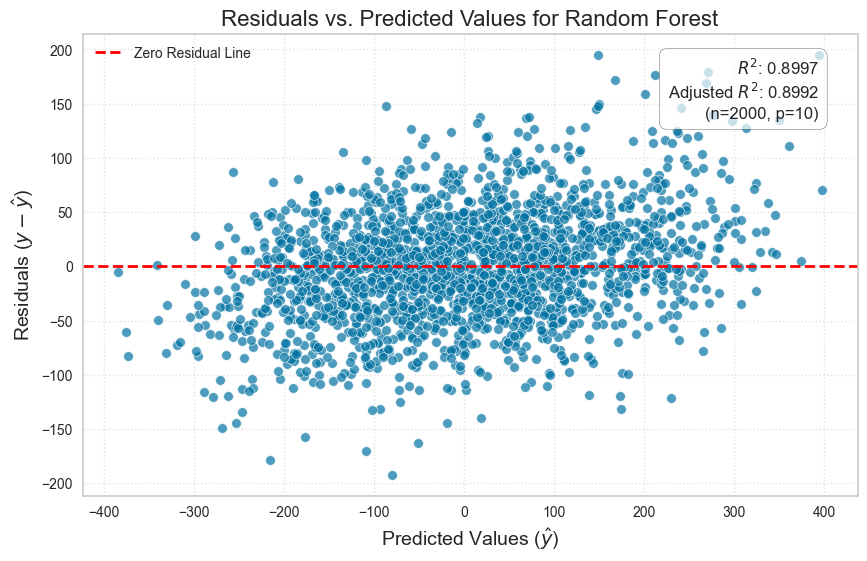

In [55]:
plot_residuals_vs_predictions(
    y_true=y_test, 
    y_pred=y_test_pred,
    X_test=X_test,
    model_name="Random Forest"
)

## 2.2 Distribucion de los errores 

In [56]:
def plot_true_vs_predicted(y_true, y_pred, model_name="Regression Model"):
    """
    Plots the true values (y_true) against the predicted values (y_pred)
    and includes the identity line (y = x).

    Parameters:
    - y_true (array-like): The true target values (y).
    - y_pred (array-like): The predicted values from the model (ŷ).
    - model_name (str): The name of the model to display in the title.
    """
    # 1. Initialize the plot
    plt.figure(figsize=(10, 6))
    
    # 2. Create the scatter plot
    # Use Seaborn's regplot for a scatter plot with a smoother option 
    # (though a simple scatter is often best for this visualization)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.7)
    
    # 3. Determine plot limits for the identity line
    # The identity line should span the minimum to maximum value of both true and predicted data
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    
    # Create the identity line (y = x)
    x_identity = np.linspace(min_val, max_val, 100)
    
    # 4. Add the identity line
    plt.plot(
        x_identity, 
        x_identity, 
        color='red', 
        linestyle='--', 
        linewidth=2, 
        label='Identity Line ($y = \hat{y}$)'
    )
    
    # 5. Add titles and labels
    plt.title(f'True Values vs. Predicted Values for {model_name}', fontsize=16)
    plt.xlabel('True Values ($y$)', fontsize=14)
    plt.ylabel('Predicted Values ($\hat{y}$)', fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # 6. Ensure aspect ratio is equal (optional, but good practice for y=x line)
    plt.axis('equal') 
    
    # 7. Show the plot
    plt.legend()
    plt.show()

<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
<>:34: SyntaxWarning: invalid escape sequence '\h'
<>:40: SyntaxWarning: invalid escape sequence '\h'
/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_39856/3349207615.py:34: SyntaxWarning: invalid escape sequence '\h'
  label='Identity Line ($y = \hat{y}$)'
/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_39856/3349207615.py:40: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted Values ($\hat{y}$)', fontsize=14)


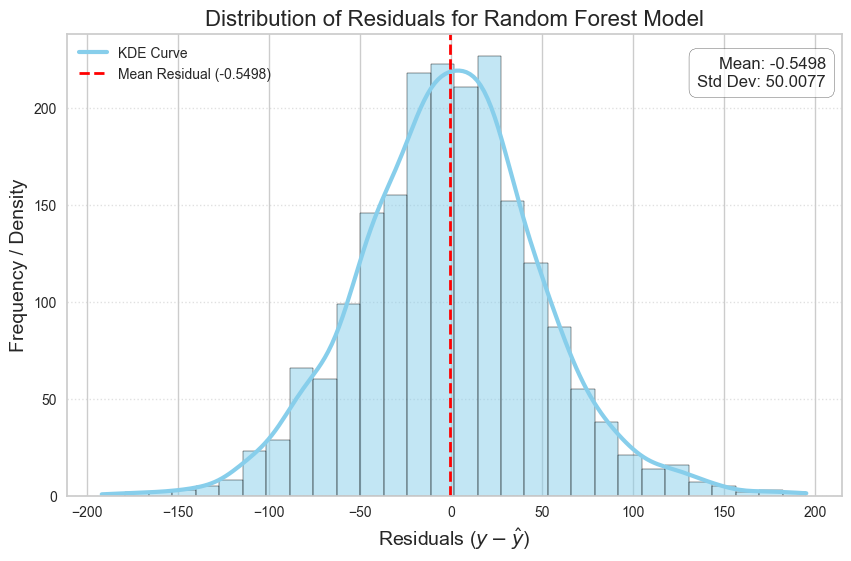

In [57]:
plot_residuals_distribution(
    y_true=y_test, 
    y_pred=y_test_pred, 
    model_name="Random Forest Model"
)

## 2.3 Predicciones vs Valores Reales

In [58]:
def plot_residuals_distribution(y_true, y_pred, model_name="Regression Model"):
    """
    Plots the distribution of the residuals (y_true - y_pred) using a histogram
    and a Kernel Density Estimate (KDE).

    Parameters:
    - y_true (array-like): The true target values (y).
    - y_pred (array-like): The predicted values from the model (ŷ).
    - model_name (str): The name of the model to display in the title.
    """
    # 1. Calculate the residuals
    residuals = y_true - y_pred
    
    # 2. Calculate key statistics
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)

    # 3. Initialize the plot
    plt.figure(figsize=(10, 6))
    
    # 4. Create the histogram and KDE plot
    # The 'kde=True' argument adds the smooth density curve
    sns.histplot(
        residuals, 
        bins=30, 
        kde=True, 
        color='skyblue', 
        edgecolor='black',
        line_kws={'linewidth': 3, 'color': 'darkblue', 'label': 'KDE Curve'}
    )
    
    # 5. Add a vertical line at the mean of the residuals
    plt.axvline(
        x=mean_residual, 
        color='red', 
        linestyle='--', 
        linewidth=2, 
        label=f'Mean Residual ({mean_residual:.4f})'
    )
    
    # 6. Add titles and labels
    plt.title(f'Distribution of Residuals for {model_name}', fontsize=16)
    plt.xlabel('Residuals ($y - \hat{y}$)', fontsize=14)
    plt.ylabel('Frequency / Density', fontsize=14)
    
    # 7. Add text box for statistics
    stats_text = (
        f'Mean: {mean_residual:.4f}\n'
        f'Std Dev: {std_residual:.4f}'
    )
    plt.text(
        x=0.98, y=0.95, 
        s=stats_text, 
        transform=plt.gca().transAxes, 
        verticalalignment='top', 
        horizontalalignment='right',
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', alpha=0.7)
    )
    
    # 8. Show the plot
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6, axis='y')
    plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\h'
<>:43: SyntaxWarning: invalid escape sequence '\h'
/var/folders/xp/09_m9yj956x3kbv7qgpqgd6r0000gn/T/ipykernel_39856/2657756475.py:43: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Residuals ($y - \hat{y}$)', fontsize=14)


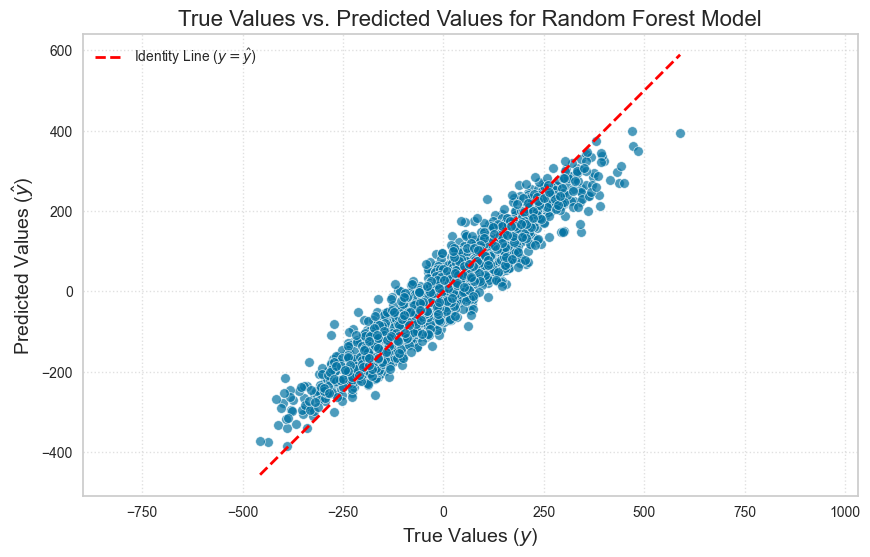

In [59]:
plot_true_vs_predicted(
    y_true=y_test, 
    y_pred=y_test_pred, 
    model_name="Random Forest Model"
)